# Chapter 30 — Random Numbers and Reproducibility

Language models use randomness for parameter initialization, training-batch order, generated-token sampling, and techniques such as dropout.

Randomness creates useful variation, but uncontrolled variation makes teaching and debugging difficult.

A random seed makes a pseudorandom sequence repeatable when the same generator receives the same calls in the same order.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain why language-model code uses randomness.
2. Explain seeds, pseudorandom generators, and random state.
3. Seed Python's module-level generator with `random.seed`.
4. Seed NumPy's legacy module-level generator with `np.random.seed`.
5. Create independent Python and NumPy generator objects.
6. Verify that equal seeds and equal call sequences reproduce results.
7. Explain why call order changes later samples.
8. Sample generated tokens from probabilities.
9. Sample training batches with and without replacement.
10. Initialize fake model parameters reproducibly.
11. Draw a deterministic histogram from seeded samples.
12. Explain the limits of reproducibility across software and hardware.

## Seeds control deterministic algorithms

Most software randomness is **pseudorandom**.

A deterministic algorithm stores an internal **state** and uses it to produce random-looking values.

A **seed** chooses a starting state.

Each random call returns a value and advances the state, so reproducibility requires the same seed and the same sequence of calls.

## Python's module-level random generator

Python's built-in `random` module provides a shared module-level generator.

Setting its seed resets that shared generator to a repeatable starting point.

In [1]:
import random

random.seed(42)

first_python_sequence = [random.random() for _ in range(5)]

random.seed(42)

second_python_sequence = [random.random() for _ in range(5)]

print("First sequence:", first_python_sequence)
print("Second sequence:", second_python_sequence)
print("Sequences match:", first_python_sequence == second_python_sequence)

assert first_python_sequence == second_python_sequence

First sequence: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Second sequence: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Sequences match: True


The values look irregular, but resetting to seed 42 reproduces the same five-value sequence exactly.

### Different seeds usually produce different sequences

The seed chooses a different starting state.

In [2]:
random.seed(42)
samples_with_seed_42 = [random.random() for _ in range(5)]

random.seed(7)
samples_with_seed_7 = [random.random() for _ in range(5)]

print("Seed 42:", samples_with_seed_42)
print("Seed 7: ", samples_with_seed_7)
print("Sequences match:", samples_with_seed_42 == samples_with_seed_7)

assert samples_with_seed_42 != samples_with_seed_7

Seed 42: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Seed 7:  [0.32383276483316237, 0.15084917392450192, 0.6509344730398537, 0.07243628666754276, 0.5358820043066892]
Sequences match: False


Different seeds are useful when we want controlled variation between experiments.

## Random state advances with every call

Setting a seed does not make every call return the same value.

It makes the whole sequence repeatable.

In [3]:
random.seed(42)
first_value = random.random()
second_value = random.random()
third_value = random.random()

random.seed(42)
replayed_values = [random.random(), random.random(), random.random()]

print("Original values:", [first_value, second_value, third_value])
print("Replayed values:", replayed_values)

assert replayed_values == [first_value, second_value, third_value]

Original values: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926]
Replayed values: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926]


If an extra random call is inserted, every later consumer receives a different point in the sequence.

In [4]:
random.seed(42)
value_without_extra_call = random.random()

random.seed(42)
discarded_value = random.random()
value_after_extra_call = random.random()

print("Without an extra call:", value_without_extra_call)
print("Discarded first value:", discarded_value)
print("After an extra call:", value_after_extra_call)
print("Final values match:", value_without_extra_call == value_after_extra_call)

Without an extra call: 0.6394267984578837
Discarded first value: 0.6394267984578837
After an extra call: 0.025010755222666936
Final values match: False


The seed is unchanged, but the call sequence changed.

That distinction explains many apparent reproducibility failures.

## Prefer independent Python generator objects

`random.seed` controls shared module state, so an unrelated call elsewhere can affect later results.

A dedicated `random.Random(seed)` object owns an independent state and makes that dependency explicit.

In [5]:
first_python_generator = random.Random(42)
second_python_generator = random.Random(42)

first_local_sequence = [first_python_generator.random() for _ in range(5)]
second_local_sequence = [second_python_generator.random() for _ in range(5)]

print("First local sequence:", first_local_sequence)
print("Second local sequence:", second_local_sequence)

assert first_local_sequence == second_local_sequence

First local sequence: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]
Second local sequence: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]


Independent generators reduce hidden coupling between functions, tests, and notebook sections.

We will use dedicated generators for most remaining examples.

## Sample integers and choices

Python's `randint(0, 9)` includes both endpoints, while `choice` samples one list item uniformly.

In [6]:
python_generator = random.Random(42)

random_indices = [python_generator.randint(0, 9) for _ in range(10)]
tokens = ["cat", "dog", "bird"]
uniform_tokens = [python_generator.choice(tokens) for _ in range(10)]

print("Random integer indexes:", random_indices)
print("Uniform token choices:", uniform_tokens)

Random integer indexes: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9]
Uniform token choices: ['dog', 'cat', 'cat', 'cat', 'cat', 'cat', 'bird', 'bird', 'cat', 'bird']


## Sample tokens from probabilities

Generated tokens are usually sampled from unequal next-token probabilities rather than uniformly.

The helper accepts its generator explicitly so callers control the random state.

In [7]:
def sample_token(
    tokens: list[str],
    probabilities: list[float],
    random_generator: random.Random,
) -> str:
    if len(tokens) == 0:
        raise ValueError("tokens must not be empty.")

    if len(tokens) != len(probabilities):
        raise ValueError("tokens and probabilities must have the same length.")

    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities must not be negative.")

    probability_sum = sum(probabilities)

    if abs(probability_sum - 1.0) > 1e-12:
        raise ValueError(f"Probabilities must add up to 1. Received {probability_sum}.")

    return random_generator.choices(
        population=tokens,
        weights=probabilities,
        k=1,
    )[0]

In [8]:
tokens = ["cat", "dog", "bird"]
probabilities = [0.50, 0.30, 0.20]

first_generation_generator = random.Random(42)
second_generation_generator = random.Random(42)

first_sampled_tokens = [
    sample_token(tokens, probabilities, first_generation_generator) for _ in range(12)
]
second_sampled_tokens = [
    sample_token(tokens, probabilities, second_generation_generator) for _ in range(12)
]

print("First sampled sequence:", first_sampled_tokens)
print("Second sampled sequence:", second_sampled_tokens)

assert first_sampled_tokens == second_sampled_tokens

First sampled sequence: ['dog', 'cat', 'cat', 'cat', 'dog', 'dog', 'bird', 'cat', 'cat', 'cat', 'cat', 'dog']
Second sampled sequence: ['dog', 'cat', 'cat', 'cat', 'dog', 'dog', 'bird', 'cat', 'cat', 'cat', 'cat', 'dog']


The sequence is reproducible, but it still contains lower-probability choices because sampling preserves uncertainty.

## NumPy has separate random state

Python's generator and NumPy's generator are independent.

The requested legacy pattern `np.random.seed(42)` resets NumPy's shared legacy generator, not Python's generator.

In [9]:
import numpy as np

np.random.seed(42)
first_legacy_numpy_sequence = np.random.random(size=5)

np.random.seed(42)
second_legacy_numpy_sequence = np.random.random(size=5)

print("First NumPy sequence:", first_legacy_numpy_sequence)
print("Second NumPy sequence:", second_legacy_numpy_sequence)
print(
    "Sequences match:",
    np.array_equal(first_legacy_numpy_sequence, second_legacy_numpy_sequence),
)

assert np.array_equal(first_legacy_numpy_sequence, second_legacy_numpy_sequence)

First NumPy sequence: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Second NumPy sequence: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Sequences match: True


Setting `random.seed(42)` does not set NumPy's state, and setting `np.random.seed(42)` does not set Python's state.

Code that uses both shared generators must seed both explicitly.

In [10]:
random.seed(42)
np.random.seed(42)

python_samples = [random.random() for _ in range(4)]
numpy_samples = np.random.random(size=4)

print("Python samples:", python_samples)
print("NumPy samples:", numpy_samples)
print("The sequences differ because the generators and algorithms differ.")

Python samples: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275]
NumPy samples: [0.37454012 0.95071431 0.73199394 0.59865848]
The sequences differ because the generators and algorithms differ.


## Prefer NumPy's modern `Generator`

NumPy recommends creating a local generator with `np.random.default_rng(seed)` for new code.

Like `random.Random`, it avoids hidden dependence on a shared module-level state.

In [11]:
first_numpy_generator = np.random.default_rng(42)
second_numpy_generator = np.random.default_rng(42)

first_numpy_sequence = first_numpy_generator.random(size=5)
second_numpy_sequence = second_numpy_generator.random(size=5)

print("First Generator sequence:", first_numpy_sequence)
print("Second Generator sequence:", second_numpy_sequence)

assert np.array_equal(first_numpy_sequence, second_numpy_sequence)

First Generator sequence: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Second Generator sequence: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]


The modern generator's methods include `random`, `integers`, `choice`, and `normal`.

Its `integers(low, high)` excludes the upper endpoint, unlike Python's inclusive `randint`.

In [12]:
numpy_generator = np.random.default_rng(42)

random_token_ids = numpy_generator.integers(
    low=0,
    high=10,
    size=(2, 5),
)

print("Random token-ID batch:")
print(random_token_ids)
print("Shape:", random_token_ids.shape)
print("Minimum ID:", random_token_ids.min())
print("Maximum ID:", random_token_ids.max())

Random token-ID batch:
[[0 7 6 4 4]
 [8 0 6 2 0]]
Shape: (2, 5)
Minimum ID: 0
Maximum ID: 8


The `(2, 5)` shape can represent two examples with five token positions each.

## Initialize fake parameters reproducibly

An embedding table shaped `vocabulary size × embedding dimension` often begins with small random values.

These values are illustrative initial parameters rather than trained embeddings.

In [13]:
vocabulary_size = 6
embedding_dimension = 4

first_parameter_generator = np.random.default_rng(42)
second_parameter_generator = np.random.default_rng(42)

first_embedding_table = first_parameter_generator.normal(
    loc=0.0,
    scale=0.1,
    size=(vocabulary_size, embedding_dimension),
)
second_embedding_table = second_parameter_generator.normal(
    loc=0.0,
    scale=0.1,
    size=(vocabulary_size, embedding_dimension),
)

print("Embedding-table shape:", first_embedding_table.shape)
print("First embedding table:")
print(first_embedding_table)
print("Tables match:", np.array_equal(first_embedding_table, second_embedding_table))

assert np.array_equal(first_embedding_table, second_embedding_table)

Embedding-table shape: (6, 4)
First embedding table:
[[ 0.03047171 -0.10399841  0.07504512  0.09405647]
 [-0.19510352 -0.13021795  0.01278404 -0.03162426]
 [-0.00168012 -0.08530439  0.0879398   0.07777919]
 [ 0.00660307  0.11272412  0.04675093 -0.08592925]
 [ 0.03687508 -0.09588826  0.08784503 -0.00499259]
 [-0.01848624 -0.06809295  0.12225413 -0.01545295]]
Tables match: True


Equal seeds and equal calls produce equal initial parameters, which helps isolate later code changes during debugging.

## Call order changes which values reach each parameter

Resetting a seed reproduces the stream, but changing object-creation order assigns different sections of that stream to each object.

In [14]:
first_order_generator = np.random.default_rng(42)
embedding_first = first_order_generator.normal(scale=0.02, size=(8, 3))
weights_second = first_order_generator.normal(scale=0.02, size=(3, 5))

reversed_order_generator = np.random.default_rng(42)
weights_first = reversed_order_generator.normal(scale=0.02, size=(3, 5))
embedding_second = reversed_order_generator.normal(scale=0.02, size=(8, 3))

print(
    "Embedding tables match after reversal:",
    np.array_equal(embedding_first, embedding_second),
)
print(
    "Weight matrices match after reversal:",
    np.array_equal(weights_second, weights_first),
)

Embedding tables match after reversal: False
Weight matrices match after reversal: False


The generator reproduced its sequence, but each parameter consumed a different part of it.

## Sample training batches

Sampling without replacement prevents an example from appearing twice in the same batch.

Python's `sample` performs this kind of selection.

In [15]:
examples = [f"example {index}" for index in range(10)]

first_batch_generator = random.Random(42)
second_batch_generator = random.Random(42)

first_batch = first_batch_generator.sample(examples, k=4)
second_batch = second_batch_generator.sample(examples, k=4)

print("First batch:", first_batch)
print("Second batch:", second_batch)

assert first_batch == second_batch
assert len(set(first_batch)) == len(first_batch)

First batch: ['example 1', 'example 0', 'example 4', 'example 9']
Second batch: ['example 1', 'example 0', 'example 4', 'example 9']


NumPy's `choice` uses `replace=False` for sampling without replacement and `replace=True` when repeated indexes are allowed.

In [16]:
batch_generator = np.random.default_rng(42)

without_replacement = batch_generator.choice(10, size=4, replace=False)
with_replacement = batch_generator.choice(4, size=10, replace=True)

print("Without replacement:", without_replacement)
print("With replacement:", with_replacement)
print(
    "Repeated values allowed in second sample:",
    len(set(with_replacement.tolist())) < len(with_replacement),
)

Without replacement: [4 0 5 6]
With replacement: [2 0 0 2 3 2 3 2 3 2]
Repeated values allowed in second sample: True


Training pipelines may shuffle an epoch, sample batches directly, or use other valid schemes.

The intended replacement and ordering behavior should be explicit.

## Generate a reproducible fake token sequence

The following generator repeatedly samples from one fixed probability dictionary.

It demonstrates random token selection, not meaningful language modeling.

In [17]:
def generate_fake_text(
    token_probabilities: dict[str, float],
    number_of_tokens: int,
    random_generator: random.Random,
) -> str:
    if number_of_tokens < 0:
        raise ValueError("number_of_tokens must not be negative.")

    tokens = list(token_probabilities)
    probabilities = list(token_probabilities.values())
    generated_tokens = [
        sample_token(tokens, probabilities, random_generator)
        for _ in range(number_of_tokens)
    ]

    return " ".join(generated_tokens)


next_token_probabilities = {
    "the": 0.30,
    "cat": 0.25,
    "dog": 0.20,
    "sat": 0.15,
    ".": 0.10,
}

first_text = generate_fake_text(
    next_token_probabilities,
    12,
    random.Random(42),
)
second_text = generate_fake_text(
    next_token_probabilities,
    12,
    random.Random(42),
)

print("First text: ", first_text)
print("Second text:", second_text)

assert first_text == second_text

First text:  dog the the the dog dog sat the cat the the cat
Second text: dog the the the dog dog sat the cat the the cat


Passing the generator makes the function's source of randomness visible and testable.

## Draw a histogram from seeded samples

A fixed generator seed makes the 1,000 underlying sample values—and therefore the stored histogram—repeatable.

In [18]:
histogram_generator = np.random.default_rng(42)
normal_samples = histogram_generator.normal(
    loc=0.0,
    scale=1.0,
    size=1000,
)

replay_histogram_generator = np.random.default_rng(42)
replayed_normal_samples = replay_histogram_generator.normal(
    loc=0.0,
    scale=1.0,
    size=1000,
)

print("First 10 samples:", normal_samples[:10])
print("Sample shape:", normal_samples.shape)
print("Replay matches:", np.array_equal(normal_samples, replayed_normal_samples))

assert np.array_equal(normal_samples, replayed_normal_samples)

First 10 samples: [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519 -1.30217951
  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Sample shape: (1000,)
Replay matches: True


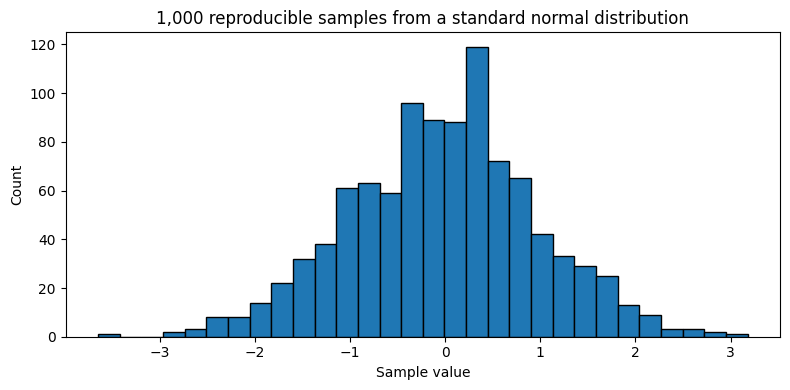

In [19]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(figsize=(8, 4))
axes.hist(normal_samples, bins=30, edgecolor="black")
axes.set_xlabel("Sample value")
axes.set_ylabel("Count")
axes.set_title("1,000 reproducible samples from a standard normal distribution")
plt.tight_layout()
plt.show()

The exact bars are reproducible because the sample data and bin count are fixed.

The values cluster around 0 with a spread controlled by scale 1.

## Dropout preview

Dropout uses a random mask during neural-network training.

This preview uses **inverted dropout**, which divides kept values by the keep probability so their expected scale is preserved.

The full training behavior will be introduced later.

In [20]:
hidden_state = np.array([0.5, -1.0, 2.0, 0.3, -0.7])
keep_probability = 0.8

first_dropout_generator = np.random.default_rng(42)
second_dropout_generator = np.random.default_rng(42)

first_dropout_mask = (
    first_dropout_generator.random(size=hidden_state.shape) < keep_probability
)
second_dropout_mask = (
    second_dropout_generator.random(size=hidden_state.shape) < keep_probability
)

dropped_hidden_state = hidden_state * first_dropout_mask / keep_probability

print("Hidden state:", hidden_state)
print("Dropout mask:", first_dropout_mask)
print("Dropped and scaled state:", dropped_hidden_state)

assert np.array_equal(first_dropout_mask, second_dropout_mask)

Hidden state: [ 0.5 -1.   2.   0.3 -0.7]
Dropout mask: [ True  True False  True  True]
Dropped and scaled state: [ 0.625 -1.25   0.     0.375 -0.875]


The same generator seed reproduces the mask, but successive calls during real training should advance rather than reuse one mask forever.

## Seed placement matters

Setting one seed and drawing two batches advances the state and usually produces two different batches.

Resetting before each draw deliberately repeats the same batch.

In [21]:
advancing_generator = random.Random(42)
advancing_first_batch = advancing_generator.sample(examples, k=4)
advancing_second_batch = advancing_generator.sample(examples, k=4)

repeated_first_batch = random.Random(42).sample(examples, k=4)
repeated_second_batch = random.Random(42).sample(examples, k=4)

print("Advancing batch 1:", advancing_first_batch)
print("Advancing batch 2:", advancing_second_batch)
print("Advancing batches match:", advancing_first_batch == advancing_second_batch)
print()
print("Repeated batch 1:", repeated_first_batch)
print("Repeated batch 2:", repeated_second_batch)
print("Repeated batches match:", repeated_first_batch == repeated_second_batch)

Advancing batch 1: ['example 1', 'example 0', 'example 4', 'example 9']
Advancing batch 2: ['example 3', 'example 2', 'example 1', 'example 5']
Advancing batches match: False

Repeated batch 1: ['example 1', 'example 0', 'example 4', 'example 9']
Repeated batch 2: ['example 1', 'example 0', 'example 4', 'example 9']
Repeated batches match: True


Repeated resetting is useful for a controlled demonstration but usually wrong when training expects fresh batches or masks.

## Reproducibility has limits

Seeds control particular pseudorandom generators, but they are not a universal guarantee across all environments.

Differences can come from:

- separate generators in different libraries;
- changed library versions or random algorithms;
- parallel execution and operation ordering;
- nondeterministic hardware kernels;
- floating-point differences across devices;
- code changes that add, remove, or reorder random calls.

Small CPU examples in this course are usually repeatable, while large training systems need additional deterministic settings and careful environment tracking.

## A clean reproducibility pipeline

The final example creates independent Python and NumPy generators, samples tokens and a batch, initializes parameters, repeats the whole sequence, and verifies equality.

In [22]:
RANDOM_SEED = 42


def run_reproducible_pipeline(
    random_seed: int,
) -> tuple[list[str], list[str], np.ndarray, np.ndarray]:
    python_generator = random.Random(random_seed)
    numpy_generator = np.random.default_rng(random_seed)

    sampled_tokens = [
        sample_token(tokens, probabilities, python_generator) for _ in range(8)
    ]
    sampled_batch = python_generator.sample(examples, k=4)
    initialized_embeddings = numpy_generator.normal(
        loc=0.0,
        scale=0.1,
        size=(6, 4),
    )
    initialized_weights = numpy_generator.normal(
        loc=0.0,
        scale=0.1,
        size=(4, 5),
    )

    return (
        sampled_tokens,
        sampled_batch,
        initialized_embeddings,
        initialized_weights,
    )


first_pipeline_run = run_reproducible_pipeline(RANDOM_SEED)
second_pipeline_run = run_reproducible_pipeline(RANDOM_SEED)

assert first_pipeline_run[0] == second_pipeline_run[0]
assert first_pipeline_run[1] == second_pipeline_run[1]
assert np.array_equal(first_pipeline_run[2], second_pipeline_run[2])
assert np.array_equal(first_pipeline_run[3], second_pipeline_run[3])

print("Reproducibility pipeline")
print("-" * 48)
print("Sampled tokens:", first_pipeline_run[0])
print("Sampled batch:", first_pipeline_run[1])
print("Embedding shape:", first_pipeline_run[2].shape)
print("Weight shape:", first_pipeline_run[3].shape)
print("All repeated results match.")

Reproducibility pipeline
------------------------------------------------
Sampled tokens: ['dog', 'cat', 'cat', 'cat', 'dog', 'dog', 'bird', 'cat']
Sampled batch: ['example 6', 'example 0', 'example 8', 'example 7']
Embedding shape: (6, 4)
Weight shape: (4, 5)
All repeated results match.


## What not to do

- Do not assume Python and NumPy share one random state.
- Do not expect equal seeds to compensate for different call order.
- Do not reset a seed before every training batch or dropout mask unless repetition is intentional.
- Do not hide a function's dependence on shared random state when a generator can be passed explicitly.
- Do not treat one seed as a universal guarantee across libraries, versions, devices, and hardware kernels.
- Do not confuse reproducibility with an explanation of model behavior.

## Gotchas

Pseudorandom generators are deterministic state machines that produce random-looking sequences.

Every random call advances state, so same seed plus same calls in the same order is the key condition.

`random.seed` and `np.random.seed` control separate shared generators.

Dedicated `random.Random` and `np.random.Generator` objects make state ownership clearer.

Changing initialization or sampling order changes which values reach each object.

Reproducibility across complete neural-network systems requires more than setting two seeds.

## Takeaways

Language models use randomness for initialization, batch selection, token sampling, and training techniques such as dropout.

A seed chooses a pseudorandom generator's starting state, while every random call advances that state.

The module-level patterns `random.seed(42)` and `np.random.seed(42)` are useful to understand, but independent generator objects reduce hidden coupling in new code.

Seeds make teaching, debugging, and experiment comparisons easier, but reproducibility also depends on call order, software, hardware, and deterministic execution settings.

## What comes next

The next chapter introduces embedding lookup.

We will use token IDs shaped `batch size × context length` to select rows from an embedding table and produce embeddings shaped `batch size × context length × embedding dimension`.